In [16]:
import os
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from torch.utils.data import Dataset, DataLoader, random_split
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, Callback
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [17]:
class VGGBlock(nn.Module):
    def __init__(self, in_channels, middle_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, middle_channels, 3, padding=1),
            nn.BatchNorm2d(middle_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(middle_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

In [18]:
class UNetPlusPlus(pl.LightningModule):
    def __init__(self, in_channels=3, out_classes=1, lr=3e-4):
        super().__init__()
        self.save_hyperparameters()
        nb_filter = [32, 64, 128, 256, 512] 

        self.pool = nn.MaxPool2d(2, 2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # Nodes (Nested Skip Pathways) 
        self.conv0_0 = VGGBlock(in_channels, nb_filter[0], nb_filter[0])
        self.conv1_0 = VGGBlock(nb_filter[0], nb_filter[1], nb_filter[1])
        self.conv2_0 = VGGBlock(nb_filter[1], nb_filter[2], nb_filter[2])
        self.conv3_0 = VGGBlock(nb_filter[2], nb_filter[3], nb_filter[3])
        self.conv4_0 = VGGBlock(nb_filter[3], nb_filter[4], nb_filter[4])

        self.conv0_1 = VGGBlock(nb_filter[0]+nb_filter[1], nb_filter[0], nb_filter[0])
        self.conv1_1 = VGGBlock(nb_filter[1]+nb_filter[2], nb_filter[1], nb_filter[1])
        self.conv2_1 = VGGBlock(nb_filter[2]+nb_filter[3], nb_filter[2], nb_filter[2])
        self.conv3_1 = VGGBlock(nb_filter[3]+nb_filter[4], nb_filter[3], nb_filter[3])

        self.conv0_2 = VGGBlock(nb_filter[0]*2+nb_filter[1], nb_filter[0], nb_filter[0])
        self.conv1_2 = VGGBlock(nb_filter[1]*2+nb_filter[2], nb_filter[1], nb_filter[1])
        self.conv2_2 = VGGBlock(nb_filter[2]*2+nb_filter[3], nb_filter[2], nb_filter[2])

        self.conv0_3 = VGGBlock(nb_filter[0]*3+nb_filter[1], nb_filter[0], nb_filter[0])
        self.conv1_3 = VGGBlock(nb_filter[1]*3+nb_filter[2], nb_filter[1], nb_filter[1])

        self.conv0_4 = VGGBlock(nb_filter[0]*4+nb_filter[1], nb_filter[0], nb_filter[0])

        self.final = nn.Conv2d(nb_filter[0], out_classes, kernel_size=1)
        self.train_losses, self.val_losses = [], []

    def forward(self, input):
        x0_0 = self.conv0_0(input)
        x1_0 = self.conv1_0(self.pool(x0_0))
        x0_1 = self.conv0_1(torch.cat([x0_0, self.up(x1_0)], 1))
        x2_0 = self.conv2_0(self.pool(x1_0))
        x1_1 = self.conv1_1(torch.cat([x1_0, self.up(x2_0)], 1))
        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, self.up(x1_1)], 1))
        x3_0 = self.conv3_0(self.pool(x2_0))
        x2_1 = self.conv2_1(torch.cat([x2_0, self.up(x3_0)], 1))
        x1_2 = self.conv1_2(torch.cat([x1_0, x1_1, self.up(x2_1)], 1))
        x0_3 = self.conv0_3(torch.cat([x0_0, x0_1, x0_2, self.up(x1_2)], 1))
        x4_0 = self.conv4_0(self.pool(x3_0))
        x3_1 = self.conv3_1(torch.cat([x3_0, self.up(x4_0)], 1))
        x2_2 = self.conv2_2(torch.cat([x2_0, x2_1, self.up(x3_1)], 1))
        x1_3 = self.conv1_3(torch.cat([x1_0, x1_1, x1_2, self.up(x2_2)], 1))
        x0_4 = self.conv0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.up(x1_3)], 1))
        return self.final(x0_4)

    def hybrid_loss(self, y_hat, y):
        bce = nn.BCEWithLogitsLoss()(y_hat, y)
        p = torch.sigmoid(y_hat)
        dice_loss = 1 - (2.*(p*y).sum() + 1e-7) / (p.sum() + y.sum() + 1e-7)
        return bce + dice_loss

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.hybrid_loss(y_hat, y)
        self.log("train_loss", loss, prog_bar=True, on_epoch=True)
        return loss

    def on_train_epoch_end(self):
        self.train_losses.append(self.trainer.callback_metrics["train_loss"].item())

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.hybrid_loss(y_hat, y)
        p = torch.sigmoid(y_hat)
        dice = (2.*((p>0.5)*y).sum() + 1e-7) / ((p>0.5).sum() + y.sum() + 1e-7)
        iou = ((p>0.5)*y).sum() / (((p>0.5) + y > 0).sum() + 1e-7)
        self.log_dict({"val_loss": loss, "val_dice": dice, "val_iou": iou}, prog_bar=True, on_epoch=True)
        return loss

    def on_validation_epoch_end(self):
        if "val_loss" in self.trainer.callback_metrics:
            self.val_losses.append(self.trainer.callback_metrics["val_loss"].item())

    def configure_optimizers(self): return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)


In [19]:
class BrainDatasetV5(Dataset):
    def __init__(self, imgs, masks, transform=None):
        self.imgs, self.masks, self.transform = imgs, masks, transform
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        img = cv2.resize(cv2.cvtColor(cv2.imread(self.imgs[i]), cv2.COLOR_BGR2RGB), (256, 256))
        mask = cv2.resize(cv2.imread(self.masks[i], 0), (256, 256)) / 255.0
        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img, mask = aug['image'], aug['mask']
        return img.float()/255., mask.unsqueeze(0).float()

In [20]:
class ComprehensiveLogger(Callback):
    def on_validation_epoch_end(self, trainer, pl_module):
        m = trainer.callback_metrics
        with open("unet_plus_v5_log.txt", "a") as f:
            f.write(f"Epoch {trainer.current_epoch}: Loss {m.get('val_loss', 0):.4f} | "
                    f"Dice {m.get('val_dice', 0):.4f} | IoU {m.get('val_iou', 0):.4f}\n")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name    | Type      | Params | Mode  | FLOPs
-------------------------------------------------------
0  | pool    | MaxPool2d | 0      | train | 0    
1  | up      | Upsample  | 0      | train | 0    
2  | conv0_0 | VGGBlock  | 10.3 K | train | 0    
3  | conv1_0 | VGGBlock  | 55.7 K | train | 0    
4  | conv2_0 | VGGBlock  | 221 K  | train | 0    
5  | conv3_0 | VGGBlock  | 886 K  | train | 0    
6  | conv4_0 | VGGBlock  | 3.5 M  | train | 0    
7  | conv0_1 | VGGBlock  | 37.1 K | train | 0    
8  | conv1_1 | VGGBlock  | 147 K  | train | 0    
9  | conv2_1 | VGGBlock  | 590 K  | train | 0    
10 | conv3_1 | VGGBlock  | 2.4 M  | train

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


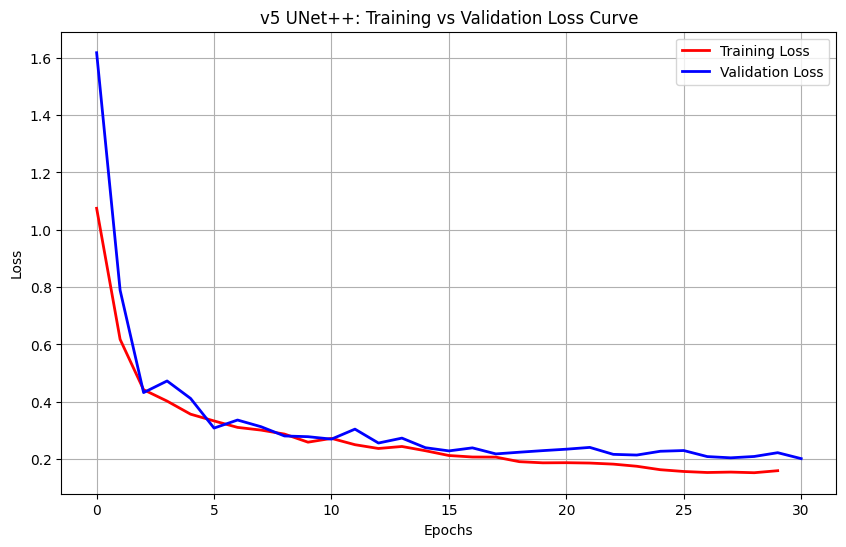

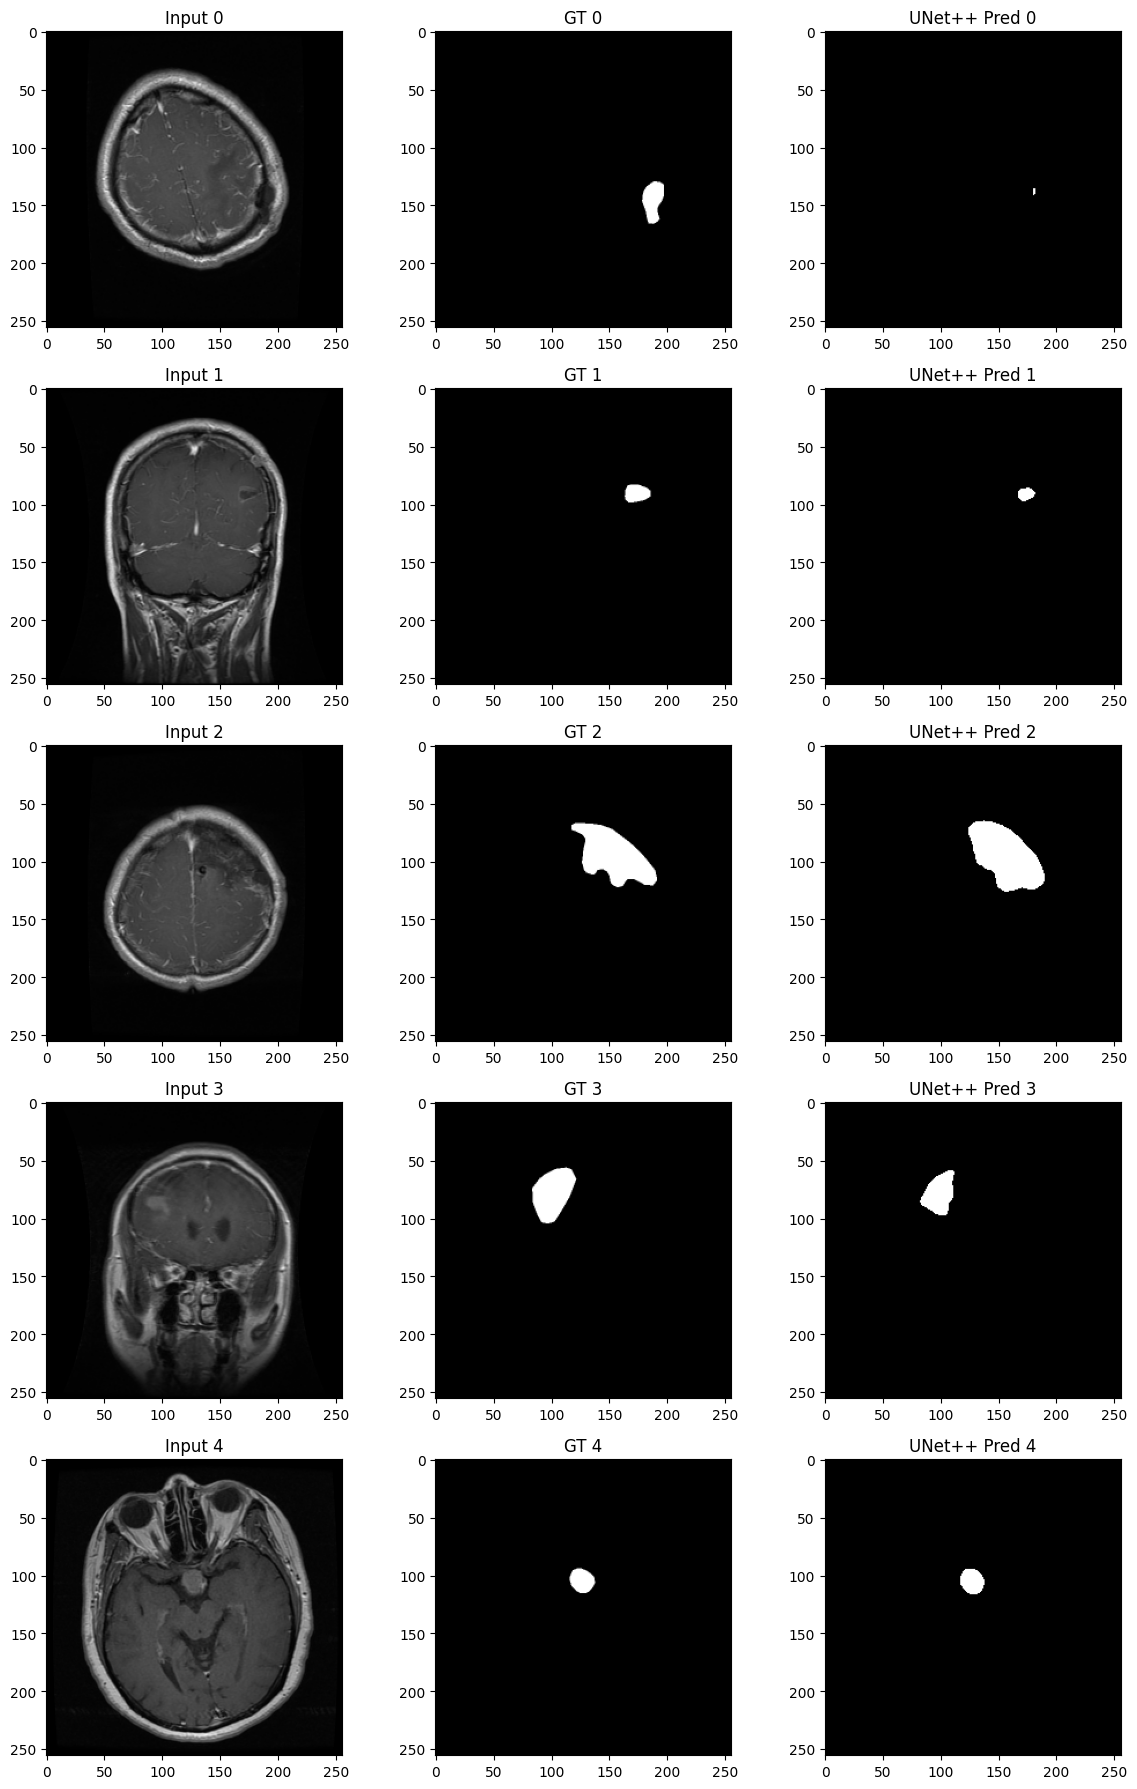

v5 Complete. Metrics logged in unet_plus_v5_log.txt. Best model: /home/linux-hasan/projects/samsung/lightning_logs/version_17/checkpoints/best_unet_plus.ckpt


In [21]:
def run_v5_experiment():
    img_list = sorted(glob("dataset/images/*.png"))
    mask_list = sorted(glob("dataset/masks/*.png"))
    
    # Advanced Elastic Augmentation
    train_aug = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.ElasticTransform(alpha=1, sigma=50, p=0.2),
        A.ShiftScaleRotate(shift_limit=0.1, rotate_limit=15, p=0.5),
        ToTensorV2()
    ])
    val_aug = A.Compose([ToTensorV2()])
    
    ds = BrainDatasetV5(img_list, mask_list)
    tr_len = int(len(ds)*0.8); vl_len = int(len(ds)*0.1)
    train, val, test = random_split(ds, [tr_len, vl_len, len(ds)-tr_len-vl_len])
    train.dataset.transform = train_aug
    val.dataset.transform = val_aug; test.dataset.transform = val_aug
    
    model = UNetPlusPlus()
    checkpoint = ModelCheckpoint(monitor="val_dice", mode="max", save_top_k=1, filename="best_unet_plus")
    
    trainer = pl.Trainer(max_epochs=30, callbacks=[checkpoint, ComprehensiveLogger()], accelerator="auto")
    trainer.fit(model, DataLoader(train, batch_size=4, shuffle=True), DataLoader(val, batch_size=4))

    
    plt.figure(figsize=(10, 6))
    plt.plot(model.train_losses, color='red', label='Training Loss', linewidth=2)
    plt.plot(model.val_losses, color='blue', label='Validation Loss', linewidth=2)
    plt.title("v5 UNet++: Training vs Validation Loss Curve")
    plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)
    plt.savefig("loss_curve_v5.png"); plt.show()

    best_model = UNetPlusPlus.load_from_checkpoint(checkpoint.best_model_path).to("cpu").eval()
    fig, axes = plt.subplots(5, 3, figsize=(12, 18))
    for i in range(5):
        img, mask = test[i]
        with torch.no_grad(): pred = torch.sigmoid(best_model(img.unsqueeze(0))) > 0.5
        axes[i,0].imshow(img.permute(1,2,0)); axes[i,0].set_title(f"Input {i}")
        axes[i,1].imshow(mask.squeeze(), cmap='gray'); axes[i,1].set_title(f"GT {i}")
        axes[i,2].imshow(pred.squeeze(), cmap='gray'); axes[i,2].set_title(f"UNet++ Pred {i}")
    plt.tight_layout(); plt.savefig("v5_visual_results.png"); plt.show()
    print(f"v5 Complete. Metrics logged in unet_plus_v5_log.txt. Best model: {checkpoint.best_model_path}")

if __name__ == "__main__":
    run_v5_experiment()